## Import all required libraries and modules

In [64]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set_style("whitegrid")
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

**Load the Dataset**

In [65]:
df = pd.read_csv("C:\\Users\\sanja\\anaconda_projects\\OIBSIP\\Task_3_Car_Price_Prediction\\Data\\car_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## STEP 1: EDA

In [66]:
# Structure check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [67]:
df.shape

(301, 9)

In [68]:
# Summary Stats
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [69]:
# Inspecting the missing values
miss_val = df.isnull().sum()
print(f'The missing values are:\n {miss_val}')  #No missing values found

The missing values are:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [70]:
# Handling duplicate values
dup_val = df.duplicated().sum()
print(f'The number of duplicated rows are:{dup_val}')

original_row = df[df.duplicated(keep=False)]
print(f'The original & duplicated rows are: \n {original_row}')

The number of duplicated rows are:2
The original & duplicated rows are: 
     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
15    ertiga  2016           7.75          10.79       43000    Diesel   
17    ertiga  2016           7.75          10.79       43000    Diesel   
51  fortuner  2015          23.00          30.61       40000    Diesel   
93  fortuner  2015          23.00          30.61       40000    Diesel   

   Selling_type Transmission  Owner  
15       Dealer       Manual      0  
17       Dealer       Manual      0  
51       Dealer    Automatic      0  
93       Dealer    Automatic      0  


*Removed 2 duplicated records to prevent data leakage and training bias.*

In [71]:
# Dropping the duplicates
df = df.drop_duplicates()

**Create Car Age because the model doesnot understand the raw year, it sees only numbers, so we create age impact.**

In [72]:
# Create Car_Age
current_year = datetime.now().year
df['Car_Age'] = current_year - df['Year']

# Drop Year column
df.drop('Year', axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


**Drop Car_Name as it is a high cardinality text column and has many unique names. If encoded then it will create too many unnecessary columns which will increase the overfitting risk of the model. Also, the dataset in this task is small.**

In [73]:
# Drop car_name
df.drop('Car_Name', axis=1, inplace=True)
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


**EDA Visualizations**

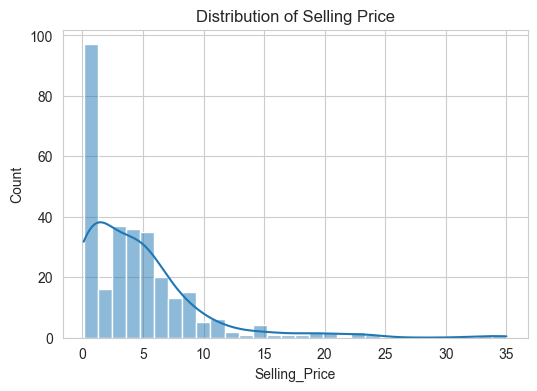

In [74]:
# Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.show()

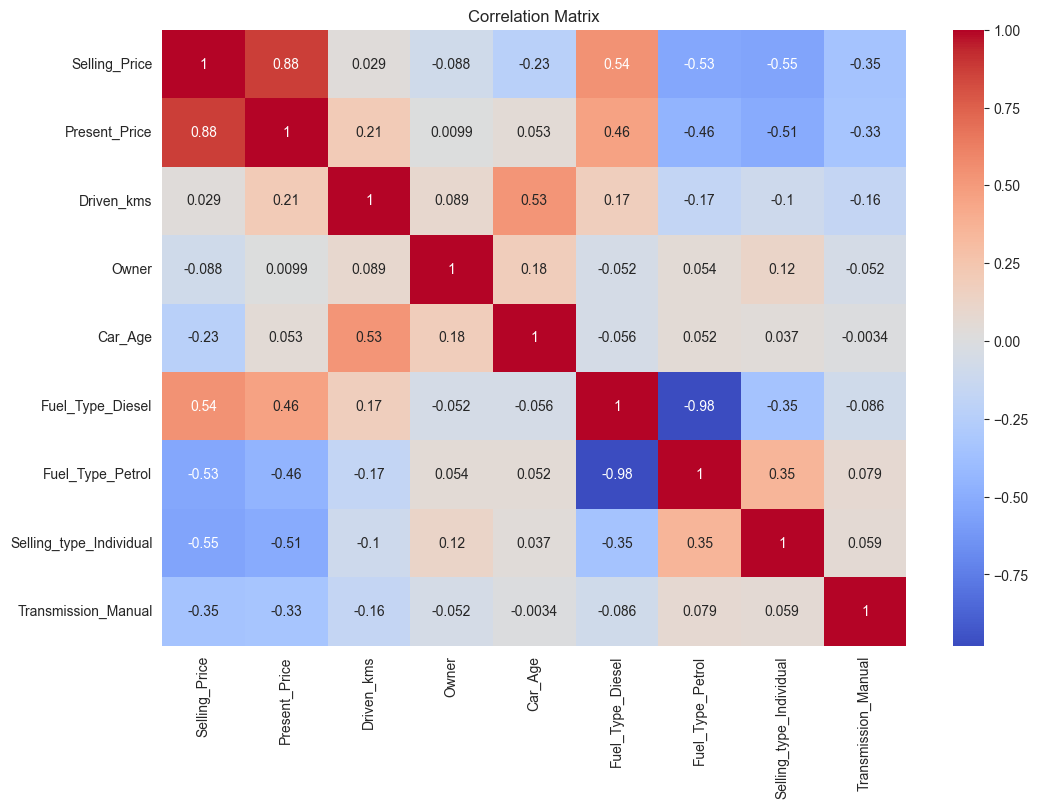

In [78]:
eda_df = df.copy()

eda_df = pd.get_dummies(eda_df, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(eda_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Correlation Matrix Summary

- **Present_Price (0.88)** shows a very strong positive correlation with Selling_Price, making it the most influential feature. This indicates resale price is heavily dependent on original showroom price.

- **Selling_type_Individual (-0.55)** has a strong negative correlation, meaning cars sold by individuals tend to have lower resale value compared to dealer sales.

- **Fuel_Type_Diesel (0.54)** positively impacts resale value, while **Fuel_Type_Petrol (-0.53)** shows a negative relationship relative to the baseline category.

- **Transmission_Manual (-0.35)** suggests manual cars generally sell for less than automatic cars.

- **Car_Age (-0.23)** shows an expected negative relationship: older cars tend to sell for lower prices.

- **Driven_kms (0.03)** and **Owner (-0.09)** have very weak correlations, indicating limited direct linear impact on price.

### Key Insight:
The dataset shows a strong linear structure dominated by `Present_Price`, suggesting linear regression models may perform well, while tree-based models could capture additional nonlinear interactions.


## STEP 2: Define X and y and perform Train-Test Split

In [79]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## STEP 3: Fit encoder ONLY on training data

*Why encode after train-test split?*

To prevent data leakage and ensure the model does not learn information from the test set during preprocessing.

In [80]:
# pd.get_dummies convert categorical variables into indicater variables (known as one-hot encoding).
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns to avoid mismatch
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

*Why align() Is Important*

Sometimes: 

- Train set has Diesel, Petrol & CNG

- Test set might not have CNG

- Column mismatch → error

- align() ensures both have same columns.

## STEP 4: Scale Data (For Linear & Ridge)

In [81]:
scaler = StandardScaler()

# Scaling only on training sets to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## STEP 5: Train Different Models
- *Linear Regression*
- *Ridge Regression*
- *Lasso Regression*

In [82]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Performance
MAE: 1.4725457508178565
RMSE: 2.524504923001869
R2 Score: 0.75272338242205


In [83]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Ridge Regression Performance
MAE: 1.4751890763299593
RMSE: 2.5219877988006583
R2 Score: 0.7532162439330127


In [84]:
lasso = Lasso(max_iter=10000)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
lasso_cv.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_cv.predict(X_test_scaled)

print("Lasso Regression Performance")
print("Best Alpha:", lasso_cv.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))

Lasso Regression Performance
Best Alpha: {'alpha': 0.1}
MAE: 1.4387901745588125
RMSE: 2.472206674716001
R2: 0.762862543755108


In [85]:
# Comparison among the Models
results_before_log = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results_before_log


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472546,2.524505,0.752723
1,Ridge Regression,1.475189,2.521988,0.753216
2,Lasso Regression,1.438790,2.472207,0.762863


**After observing strong right-skewness in the target variable, I applied log transformation which significantly improved linear model performance. This indicated that the nonlinearity was primarily due to scale distortion rather than complex feature interactions.**

In [86]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [87]:
lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train_log)

y_pred_log_lr = lr_log.predict(X_test_scaled)

y_pred_original_lr = np.expm1(y_pred_log_lr)

print("Linear Regression Performance (Original Scale)")
print("MAE:", mean_absolute_error(y_test, y_pred_original_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original_lr)))
print("R2 Score:", r2_score(y_test, y_pred_original_lr))

Linear Regression Performance (Original Scale)
MAE: 0.9142567189929077
RMSE: 1.5781218456868285
R2 Score: 0.9033700686253574


In [88]:
ridge_log = Ridge(alpha=1.0)
ridge_log.fit(X_train_scaled, y_train_log)

y_pred_log_ridge = ridge_log.predict(X_test_scaled)

y_pred_original_ridge = np.expm1(y_pred_log_ridge)

print("Ridge Regression Performance (Original Scale)")
print("MAE:", mean_absolute_error(y_test, y_pred_original_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_original_ridge))

Ridge Regression Performance (Original Scale)
MAE: 0.9242247234126525
RMSE: 1.5890735978108348
R2 Score: 0.9020242421201057


In [89]:
lasso_log = Lasso(max_iter=10000)

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_log_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
lasso_log_cv.fit(X_train_scaled, y_train_log)

y_pred_log_lasso = lasso_log_cv.predict(X_test_scaled)

y_pred_original_lasso = np.expm1(y_pred_log_lasso)

print("Lasso Regression Performance (Original Scale)")
print("Best Alpha:", lasso_log_cv.best_params_)
print("MAE:", mean_absolute_error(y_test, y_pred_original_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original_lasso)))
print("R2:", r2_score(y_test, y_pred_original_lasso))

Lasso Regression Performance (Original Scale)
Best Alpha: {'alpha': 0.01}
MAE: 0.9602148995915132
RMSE: 1.7035914592825345
R2: 0.8873940040994097


In [90]:
# Comparison among the Models after log transformation
results_after_log = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'MAE': [
         mean_absolute_error(y_test, y_pred_original_lr),
        mean_absolute_error(y_test, y_pred_original_ridge),
        mean_absolute_error(y_test, y_pred_original_lasso)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_original_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_original_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_original_lasso))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_original_lr),
        r2_score(y_test, y_pred_original_ridge),
        r2_score(y_test, y_pred_original_lasso)
    ]
})

results_after_log

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.914257,1.578122,0.903370
1,Ridge Regression,0.924225,1.589074,0.902024
2,Lasso Regression,0.960215,1.703591,0.887394


In [91]:
results_before_log["Target_Type"] = "Original"
results_after_log["Target_Type"] = "Log Transformed"

final_df = pd.concat([results_before_log, results_after_log], ignore_index=True)

final_df = final_df[["Target_Type", "Model", "MAE", "RMSE", "R2 Score"]]

final_df

,Target_Type,Model,MAE,RMSE,R2 Score
0,Original,Linear Regression,1.472546,2.524505,0.752723
1,Original,Ridge Regression,1.475189,2.521988,0.753216
2,Original,Lasso Regression,1.438790,2.472207,0.762863
3,Log Transformed,Linear Regression,0.914257,1.578122,0.903370
4,Log Transformed,Ridge Regression,0.924225,1.589074,0.902024
5,Log Transformed,Lasso Regression,0.960215,1.703591,0.887394


## STEP 6: Model Validation & Interpretation

**A.** *Cross Validation*

In [95]:
lr_log.fit(X_train_scaled, y_train_log)
ridge_log.fit(X_train_scaled, y_train_log)
lasso_log_cv.fit(X_train_scaled, y_train_log)

models = {
    "Linear": lr_log,
    "Ridge": ridge_log,
    "Lasso": lasso_log_cv
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train_log,
        cv=5,
        scoring='r2'
    )
    
    print(f"{name} CV R2 Mean: {scores.mean():.4f}")
    print(f"{name} CV R2 Std: {scores.std():.4f}")
    print("-" * 40)

Linear CV R2 Mean: 0.8339
Linear CV R2 Std: 0.1468
----------------------------------------
Ridge CV R2 Mean: 0.8370
Ridge CV R2 Std: 0.1399
----------------------------------------
Lasso CV R2 Mean: 0.8369
Lasso CV R2 Std: 0.1449
----------------------------------------


**B.** *Train vs Test Comparison (Overfitting Check)*

In [94]:
for name, model in models.items():
    
    train_r2 = model.score(X_train_scaled, y_train_log)
    test_r2 = model.score(X_test_scaled, y_test_log)
    
    print(f"{name} Train R2: {train_r2:.4f}")
    print(f"{name} Test R2: {test_r2:.4f}")
    print("-" * 40)


Linear Train R2: 0.9046
Linear Test R2: 0.9372
----------------------------------------
Ridge Train R2: 0.9045
Ridge Test R2: 0.9364
----------------------------------------
Lasso Train R2: 0.9039
Lasso Test R2: 0.9365
----------------------------------------


**Since log transformation significantly improved predictive performance and corrected model assumptions, further validation and interpretation were conducted only on log-transformed models.**

**C.** *Actual vs Predicted*

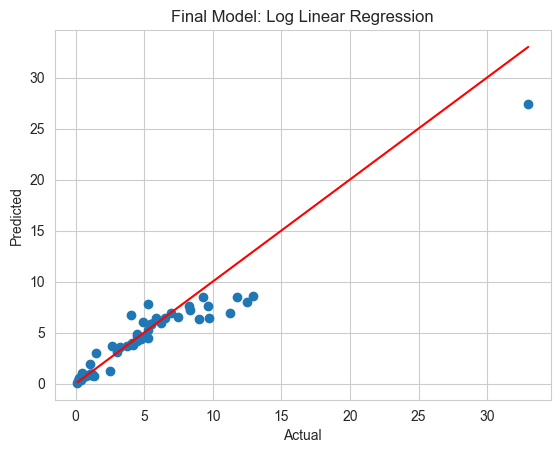

In [96]:
plt.scatter(y_test, y_pred_original_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Final Model: Log Linear Regression")
plt.show()

**D.** *Residuals analysis*

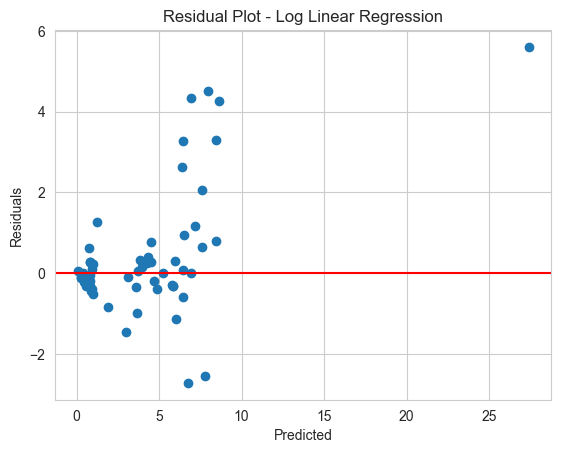

In [97]:
residuals_lr = y_test - y_pred_original_lr

plt.scatter(y_pred_original_lr, residuals_lr)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot - Log Linear Regression")
plt.show()

**E.** *Feature Importance*

In [99]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_log.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df)


                   Feature  Coefficient
6  Selling_type_Individual    -0.440544
0            Present_Price     0.345381
3                  Car_Age    -0.183310
4         Fuel_Type_Diesel     0.133495
5         Fuel_Type_Petrol     0.056772
7      Transmission_Manual    -0.043678
2                    Owner    -0.012520
1               Driven_kms    -0.001276


## 📊 Car Price Prediction Using Linear Regression

In this task, multiple regression models were evaluated using both the original and log-transformed target variable. After comparing performance metrics (MAE, RMSE, and R²), the log transformation significantly improved model performance, indicating that the target variable was positively skewed and better suited for logarithmic scaling.

Among the evaluated models (Linear, Ridge, and Lasso Regression), the Log-Transformed Linear Regression model achieved the best performance:

- **R² (Test): ~0.93**
- **Lowest RMSE and MAE**
- Stable cross-validation performance
- No evidence of overfitting (Train R² ≈ Test R²)

Residual analysis showed:
- Errors centered around zero
- No strong non-linear patterns
- Mostly constant variance

Feature importance analysis revealed that:
- **Present Price** is the strongest positive predictor.
- **Selling Type (Individual)** and **Car Age** significantly reduce resale value.
- Fuel type and transmission type have moderate influence.
- Driven kilometers and number of owners have smaller effects.

Based on performance, stability, and interpretability, **Log-Transformed Linear Regression** was selected as the final model.

This model provides strong predictive accuracy while maintaining clear business interpretability.